# Dataset: `World_Bank_Data.csv` (or similar global economic data)

# 1. Import Libraries: 
**Import SVR, StandardScaler, and basic data handling libraries.**

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2.Load Data: 
**Read the dataset containing country indicators (e.g., GDP , Exports).**

In [115]:
df = pd.read_csv('WorldBank.csv')

In [116]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,714.748450,700.408454,742.928128,761.441742,632.269428,624.224980,706.102795,766.360840,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614,5.246771,5.729495,5.060904,4.706801,4.471147,3.760466,3.921611,3.438072,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.48805,10.124611,9.451370,10.529480,10.891125,...,0.755066,0.273842,0.440954,1.514439,2.228351,2.270593,1.770314,0.535419,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,17.080013,15.197912,16.863038,22.008132,...,3.741041,4.048246,3.895215,4.458509,5.758038,6.505293,6.137617,4.156488,4.248261,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346,8.641136,8.576307,NaN,5.802677,7.707811,8.288774,9.111423,NaN,NaN


# 3.Filter Data: 
**Filter the dataframe for a specific country (e.g.,"India") and specific indicators.**

In [117]:
# Filter Data

country = "India"
indicator = "GDP (current US$)"   # Change as needed

filtered_df = df[
    (df['Country Name'] == country) &
    (df['Indicator Name'] == indicator)
]

print(filtered_df)

   Country Name Country Code     Indicator Name  Indicator Code          1960  \
47        India          IND  GDP (current US$)  NY.GDP.MKTP.CD  3.702988e+10   

            1961          1962          1963          1964          1965  ...  \
47  3.923244e+10  4.216148e+10  4.842192e+10  5.648029e+10  5.955485e+10  ...   

            2011          2012          2013          2014          2015  \
47  1.823050e+12  1.827640e+12  1.856720e+12  2.039130e+12  2.103590e+12   

            2016          2017          2018          2019  2020  
47  2.294800e+12  2.652750e+12  2.713170e+12  2.875140e+12   NaN  

[1 rows x 65 columns]


# 4. Reshape: Ensure input features (X) and target (y) are shaped correctly for scaling.

In [124]:
# Extract years and values
years = filtered_df.columns[4:]   # 1960 to 2020

X = np.array(years, dtype=int).reshape(-1, 1)
y = filtered_df.iloc[0, 4:].values.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (61, 1)
y shape: (61, 1)


In [127]:
# Convert values to numeric
y = pd.to_numeric(filtered_df.iloc[0, 4:], errors='coerce')

# Remove NaN values
y = y.dropna()

# Create X using only valid years
X = np.array(y.index, dtype=int).reshape(-1, 1)

# Convert y to numpy array
y = y.values.reshape(-1, 1)

# 6. Feature Scaling: 
**Apply StandardScaler to both X and y (SVR requires scaling).**

In [128]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling
sc_X = StandardScaler()
sc_y = StandardScaler()

X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y)

print(X_scaled.shape)
print(y_scaled.shape)

(60, 1)
(60, 1)


# 6. Train SVR: Initialize and train an SVR model (try kernel='rbf')

In [129]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf')
svr.fit(X_scaled, y_scaled.ravel())

SVR()

# 7. Predict: Predict the value for a future year (e.g., 2025). 
**Note: Remember to transform input and inverse-transform output.**

In [130]:
# Future year to predict
future_year = np.array([[2025]])

# Scale the input year
future_year_scaled = sc_X.transform(future_year)

# Predict (scaled output)
pred_scaled = svr.predict(future_year_scaled)

# Convert prediction back to original scale
pred_actual = sc_y.inverse_transform(pred_scaled.reshape(-1, 1))

print("Predicted value for 2025:", pred_actual[0][0])

Predicted value for 2025: 2467690705683.7183


# 8. Visualisation: Scatter plot the original data points.

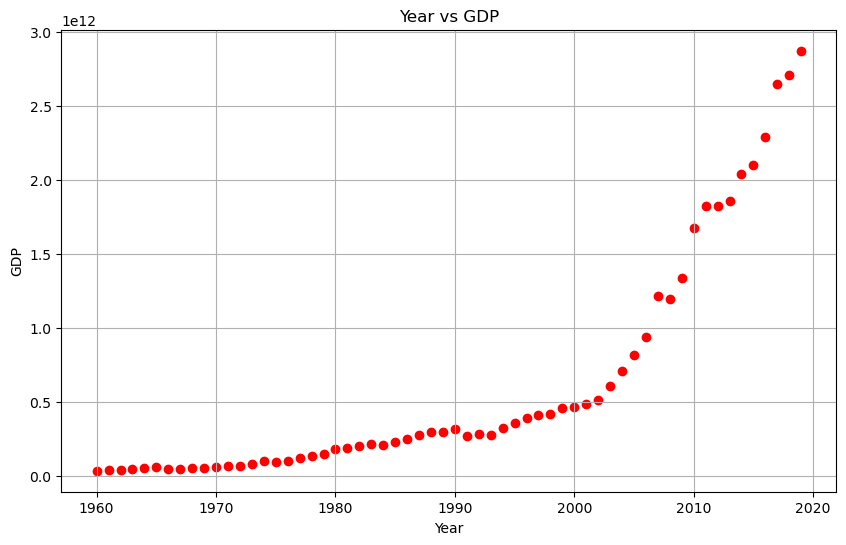

In [131]:
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='red')
plt.title('Year vs GDP')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.grid(True)

plt.show()


# 9. Visualisation: Plot the SVR regression line/curve over the data points.

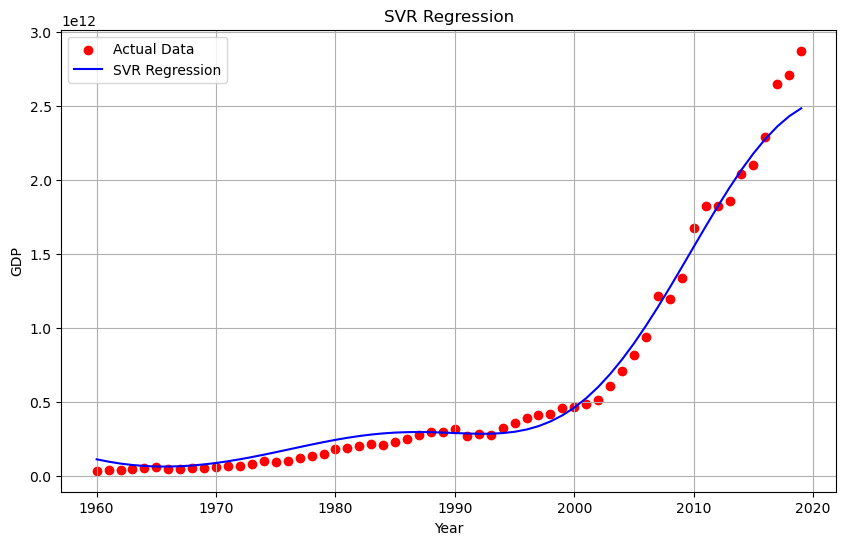

In [132]:
plt.figure(figsize=(10,6))

# original data points
plt.scatter(X, y, color='red', label='Actual Data')

# SVR regression curve
y_pred_scaled = svr.predict(X_scaled)
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

plt.plot(X, y_pred, color='blue', label='SVR Regression')

plt.title('SVR Regression')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)

plt.show()